## Single Exponential Smoothing

Exponential Smoothing model: 

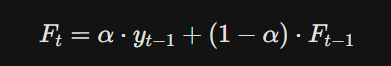

* F_t+1 is the forecast for time period t+1
* F_t is the forecast fot the period t
* A_t is the observed value in period t
* alfa is a constant between 0 and 1, called smoothing constant
* Seed forecast with last observation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfi
from statsmodels.tsa.holtwinters import SimpleExpSmoothing as ses

In [3]:
gld = yfi.download("GLD", start="2020-01-01", end="2026-03-27", progress=False)
if isinstance(gld.columns, pd.MultiIndex):
    gld.columns = gld.columns.get_level_values(0)
gdr = round(gld, 2)
gdr = gdr.resample("W").last()
values = pd.DataFrame({'alpha': np.zeros(10), 'MSE': np.zeros(10)})
alpha_val = .1
for i in range(10):
    model_final = ses(gdr['Close'])
    res = model_final.fit()
    gdr['Forecast'] = res.fittedvalues
    gdr['MSE_calc'] = (gdr['Close'] - gdr['Forecast']) ** 2
    mse_mean = gdr['MSE_calc'].mean()
    values.loc[i, 'alpha'] = alpha_val
    values.loc[i, 'MSE'] = mse_mean
    alpha_val += .1
print(values)

   alpha        MSE
0    0.1  31.236513
1    0.2  31.236513
2    0.3  31.236513
3    0.4  31.236513
4    0.5  31.236513
5    0.6  31.236513
6    0.7  31.236513
7    0.8  31.236513
8    0.9  31.236513
9    1.0  31.236513
